In [2]:
!git clone https://github.com/liquidslr/interview-company-wise-problems

Cloning into 'interview-company-wise-problems'...
remote: Enumerating objects: 13127, done.
remote: Counting objects: 100% (1384/1384), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 13127 (delta 1310), reused 1186 (delta 1186), pack-reused 11743 (from 1)
Receiving objects: 100% (13127/13127), 5.39 MiB | 29.98 MiB/s, done.
Resolving deltas: 100% (9817/9817), done.


In [6]:
dir = '/content/interview-company-wise-problems/LinkedIn'

In [8]:
import pandas as pd

csv_files = [f for f in files_in_dir if f.endswith('.csv')]

dataframes = {}
for csv_file in csv_files:
    file_path = os.path.join(dir, csv_file)
    df_name = os.path.splitext(csv_file)[0]
    dataframes[df_name] = pd.read_csv(file_path)
    print(f"Loaded '{csv_file}' into a DataFrame named '{df_name}' with {dataframes[df_name].shape[0]} rows and {dataframes[df_name].shape[1]} columns.")

print("\nAll CSV files loaded into 'dataframes' dictionary.")

Loaded '4. More Than Six Months.csv' into a DataFrame named '4. More Than Six Months' with 100 rows and 6 columns.
Loaded '1. Thirty Days.csv' into a DataFrame named '1. Thirty Days' with 10 rows and 6 columns.
Loaded '2. Three Months.csv' into a DataFrame named '2. Three Months' with 52 rows and 6 columns.
Loaded '3. Six Months.csv' into a DataFrame named '3. Six Months' with 87 rows and 6 columns.
Loaded '5. All.csv' into a DataFrame named '5. All' with 100 rows and 6 columns.

All CSV files loaded into 'dataframes' dictionary.


In [9]:
import pandas as pd

# Combine all DataFrames from the 'dataframes' dictionary into a single DataFrame
combined_df = pd.concat(dataframes.values(), ignore_index=True)

print(f"Successfully combined all CSV files into a single DataFrame with {combined_df.shape[0]} rows and {combined_df.shape[1]} columns.")
print("Here are the first 5 rows of the combined DataFrame:")
print(combined_df.head())

Successfully combined all CSV files into a single DataFrame with 349 rows and 6 columns.
Here are the first 5 rows of the combined DataFrame:
  Difficulty                          Title  Frequency  Acceptance Rate  \
0       HARD                      Max Stack      100.0         0.455318   
1     MEDIUM      Nested List Weight Sum II       93.3         0.655715   
2       HARD       All O`one Data Structure       92.1         0.441348   
3     MEDIUM  Design Authentication Manager       77.8         0.578542   
4     MEDIUM             Find the Celebrity       76.0         0.484384   

                                                Link  \
0            https://leetcode.com/problems/max-stack   
1  https://leetcode.com/problems/nested-list-weig...   
2  https://leetcode.com/problems/all-oone-data-st...   
3  https://leetcode.com/problems/design-authentic...   
4   https://leetcode.com/problems/find-the-celebrity   

                                              Topics  
0  Linked List,

In [15]:
import pandas as pd

all_topics = []

for topics_str in combined_df['Topics']:
    if pd.notna(topics_str):
        topics = [topic.strip() for topic in topics_str.split(',')]
        all_topics.extend(topics)
topic_counts = pd.Series(all_topics).value_counts()

print("Frequency of each topic:")
display(topic_counts.head(70))

Frequency of each topic:


,count
Array,155
String,78
Hash Table,77
Depth-First Search,76
Breadth-First Search,60
Tree,57
Binary Tree,53
Design,50
Dynamic Programming,50
Two Pointers,46


In [16]:
combined_df.to_csv('combined_data.csv', index=False)

combined_df saved to combined_data.csv


In [17]:
topic_counts.to_csv('topic_frequencies.csv', header=True)

topic_counts saved to topic_frequencies.csv


/tmp/ipykernel_4834/2051895772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Difficulty', y='Acceptance Rate', data=combined_df, palette='viridis')


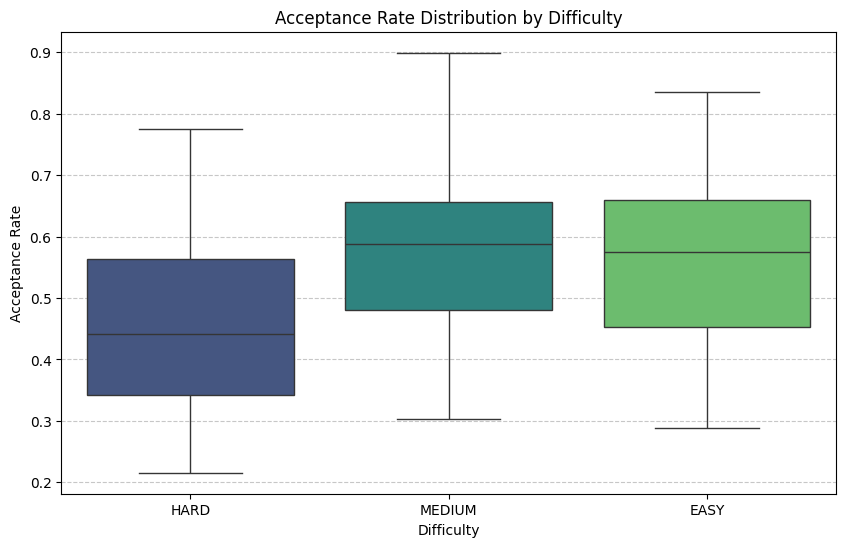

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Difficulty', y='Acceptance Rate', data=combined_df, palette='viridis')
plt.title('Acceptance Rate Distribution by Difficulty')
plt.xlabel('Difficulty')
plt.ylabel('Acceptance Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This box plot helps to visualize the spread and central tendency of acceptance rates for problems categorized by difficulty. You can observe if there's a clear trend where harder problems generally have lower acceptance rates, and also see the variability within each difficulty level.

/tmp/ipykernel_4834/1559418453.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30_topics.index, y=top_30_topics.values, palette='viridis')


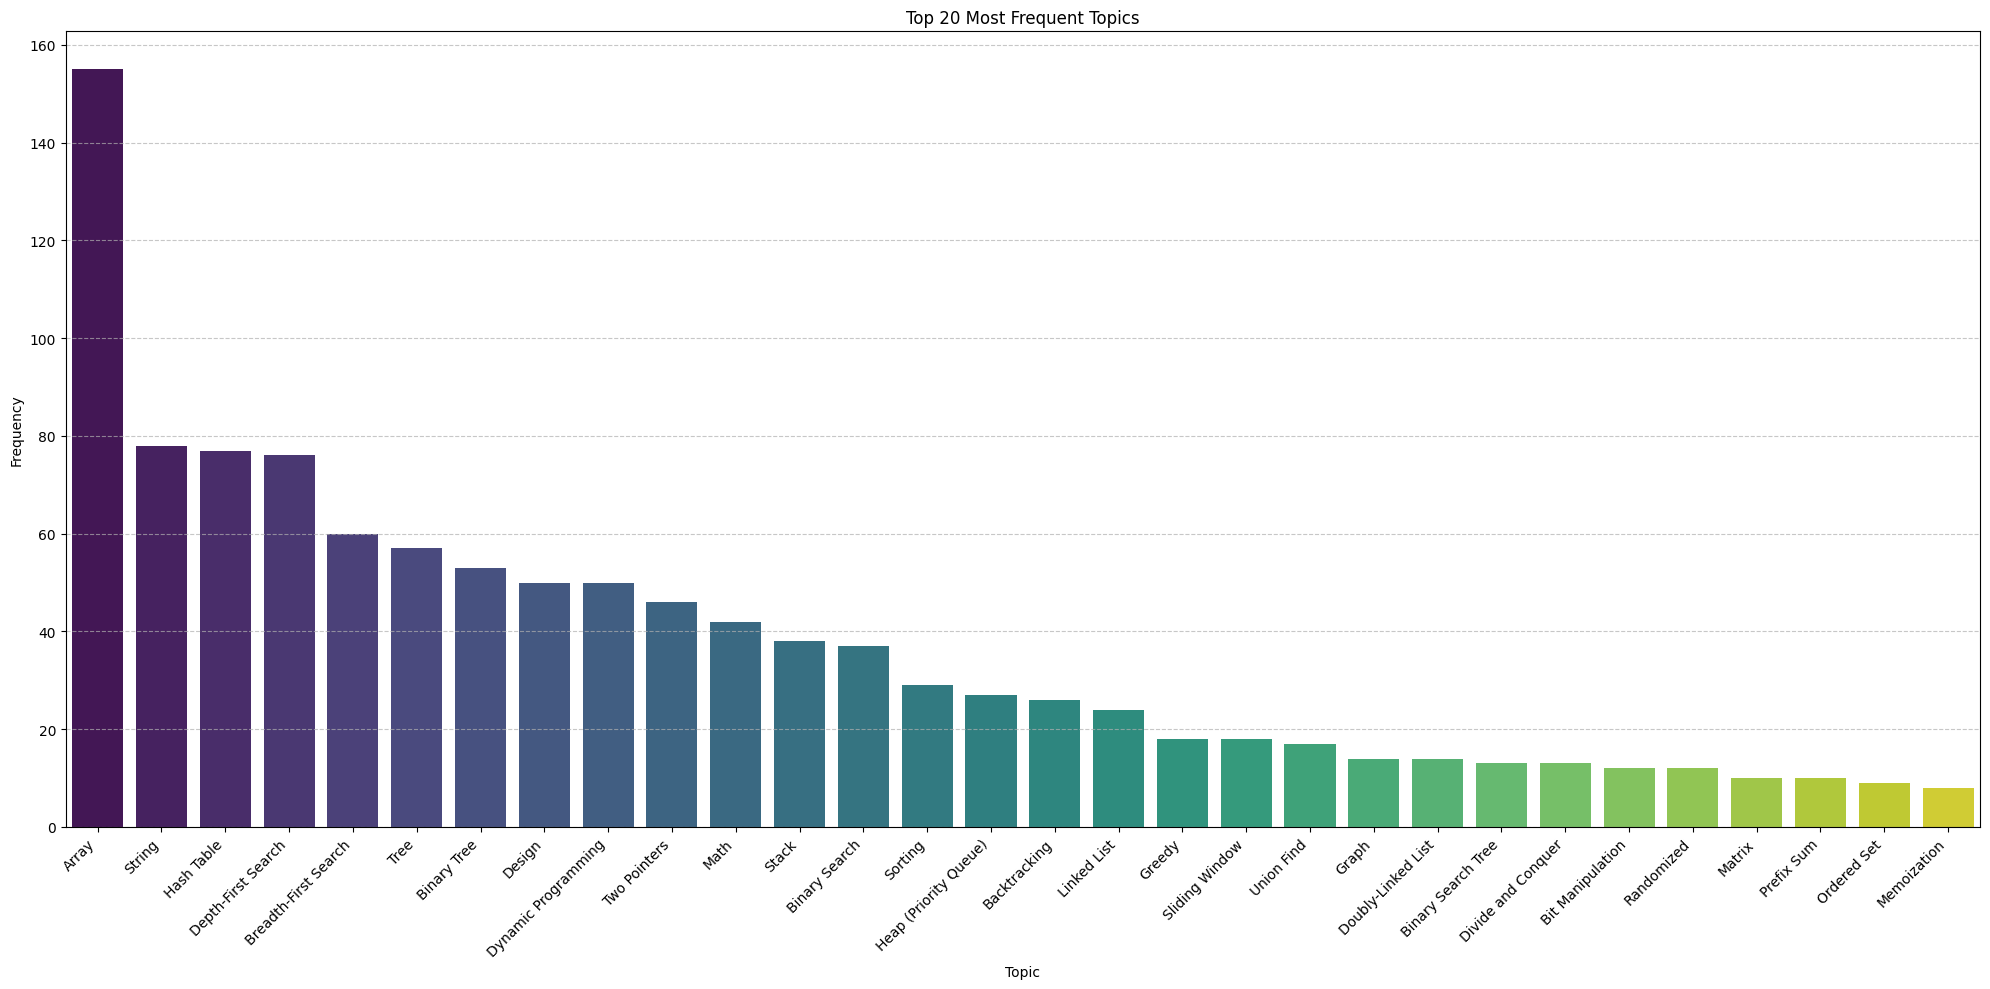

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

top_30_topics = topic_counts.head(30)

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
sns.barplot(x=top_30_topics.index, y=top_30_topics.values, palette='viridis')
plt.title('Top 20 Most Frequent Topics')
plt.xlabel('Topic')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') #
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [21]:
correlation = combined_df['Frequency'].corr(combined_df['Acceptance Rate'])
print(f"Correlation between Frequency and Acceptance Rate: {correlation:.2f}")

Correlation between Frequency and Acceptance Rate: -0.06


In [22]:
pip install wordcloud

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [24]:
topic_freq_dict = topic_counts.to_dict()

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_freq_dict)

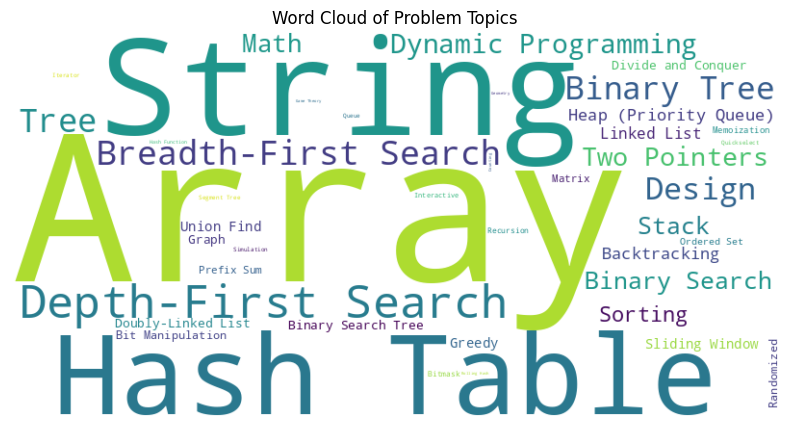

In [25]:
# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Problem Topics')
plt.show()